# Opto + dLight — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)  

This notebook demonstrates how to access each data stream in the Opto + dLight NWB files.

## About the experiment

Water-restricted mice freely nosepoked to trigger bilateral SNc laser stimulation (640 nm, 40 Hz).
Each nosepoke delivered a 1-second train of laser pulses followed by a 3-second inter-stimulation
interval. Fiber photometry (470 nm excitation, dLight1.3b dopamine indicator) simultaneously
recorded striatal dopamine dynamics. Two recording sites were used: dorsal striatum (**dStr**)
and ventral striatum (**vStr**). Multiple laser intensities (0.1, 0.2, 0.5, 1, 2 mW) were tested.

- **Mice:** 4 mice (anxa1-flp line, C57BL/6N), 20 sessions total
- **Groups:** dStr (10 sessions) and vStr (10 sessions)
- **Opsin:** ChRmine-oScarlet (AAV8-nEF-Coff/Fon-ChRmine-oScarlet, Addgene #137160)

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Raw signal (470 nm)** | `acquisition/FiberPhotometryResponseSeries` | ~60 Hz | Raw 470 nm fluorescence from DoricStudio V5 (dopamine-sensitive channel) |
| **Isosbestic reference (405 nm)** | `acquisition/FiberPhotometryResponseSeriesIsosbestic` | ~60 Hz | Raw 405 nm fluorescence from DoricStudio V5 (motion/bleaching control) |
| **Fiber photometry dF/F** | `processing/ophys/DfOverFFiberPhotometryResponseSeries` | ~60 Hz | Motion-corrected dF/F dLight1.3b dopamine signal (470 nm − 405 nm isosbestic) |
| **Optogenetic series** | `stimulus/OptogeneticSeries` | ~143 Hz | Laser power trace (watts): 0 when off, intensity when on |
| **Stimulation episodes** | `intervals/stimulation_episodes` | — | Nosepoke-triggered laser burst onset/offset times |
| **Opto metadata** | `general/lab_meta_data/optogenetic_experiment_metadata` | — | ndx-optogenetics: virus, injection sites, devices |

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Update the path below to point to your NWB file. This demo uses a full-session file.
Stub (truncated) files have the same structure but shorter time series.

In [2]:
nwb_path = "../../../nwb_output/opto_dlight/sub-776769_ses-oft_2024-03-01T10_16_32.nwb"

io = NWBHDF5IO(nwb_path, mode="r")
nwbfile = io.read()

print(f"Session ID:         {nwbfile.session_id}")
print(f"Session start:      {nwbfile.session_start_time}")
print(f"Session desc:       {nwbfile.session_description[:120].strip()}")
print(f"Subject ID:         {nwbfile.subject.subject_id}")
print(f"Species:            {nwbfile.subject.species}")
print(f"Genotype:           {nwbfile.subject.genotype}")
print(f"Strain:             {nwbfile.subject.strain}")
print(f"Sex:                {nwbfile.subject.sex}")
print(f"Institution:        {nwbfile.institution}")
print(f"Lab:                {nwbfile.lab}")
print(f"Related pubs:       {nwbfile.related_publications}")

Session ID:         opto_dlight_dStr_2.0mW
Session start:      2024-03-01 10:16:32+01:00
Session desc:       Optogenetic self-stimulation session. A water-restricted mouse freely nosepoked to trigger
bilateral SNc laser stimulati
Subject ID:         776769
Species:            Mus musculus
Genotype:           anxa1-flp
Strain:             C57BL/6N
Sex:                U
Institution:        Karolinska Institutet
Lab:                Meletis
Related pubs:       ('doi:10.1101/2024.12.22.629963',)


## 1. Fiber photometry (dLight)

Striatal dopamine dynamics were recorded using the dLight1.3b genetically encoded dopamine
indicator. Two Doric LED channels are used:

- **Signal channel** (470 nm): excites dLight1.3b for dopamine-dependent fluorescence
- **Isosbestic reference** (405 nm): motion-correction reference, insensitive to dopamine

The stored signal is the motion-corrected dF/F difference (470 nm signal − 405 nm isosbestic
reference), sampled at ~60 Hz.

Device hardware and indicator metadata are stored via
[ndx-ophys-devices](https://github.com/catalystneuro/ndx-ophys-devices):
- **ExcitationSourceModel** — Doric 470 nm and 405 nm LED models
- **OpticalFiberModel** — Doric 400 µm ceramic ferrule cannula (NA 0.22)
- **Indicator** — dLight1.3b with manufacturer and citation metadata

The processed dF/F signal is stored as a `DfOverFFiberPhotometryResponseSeries` inside the
`processing/ophys/` module via the
[ndx-fiber-photometry](https://github.com/catalystneuro/ndx-fiber-photometry) extension.
Recording location is stored using Allen Mouse Brain Atlas CCF names
(`Caudoputamen` for dStr, `Nucleus accumbens` for vStr).

**Note:** Timestamps start at ~8 s due to the fiber photometry system warm-up period.

In [3]:
fp = nwbfile.processing["ophys"]["DfOverFFiberPhotometryResponseSeries"]
signal = fp.data[:]
timestamps = fp.timestamps[:]

print(f"Description:       {fp.description}")
print(f"Unit:              {fp.unit}")
print(f"Data shape:        {signal.shape}")
print(f"Time range:        {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
print(f"Sampling rate:     ~{1 / np.median(np.diff(timestamps)):.1f} Hz")
print(f"Signal range:      {signal.min():.3f} to {signal.max():.3f} a.u.")

# Fiber photometry metadata from the lab metadata table
fp_meta = nwbfile.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table
print(f"\nRecording location:         {fp_table['location'][0]}")
print(f"Excitation wavelength:      {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:        {fp_table['emission_wavelength_in_nm'][0]} nm")

# Indicator metadata
ind = fp_table["indicator"][0]
print(f"\nIndicator label:            {ind.label}")
print(f"Indicator manufacturer:     {ind.manufacturer}")
print(f"Indicator description:      {ind.description}")

# Excitation source device instances (signal + isosbestic)
es_signal = nwbfile.devices["excitation_source_signal"]
es_isos = nwbfile.devices["excitation_source_isosbestic"]
print(f"\nSignal source (470 nm):     {es_signal.name}")
print(f"  model:                    {es_signal.model.name}  ({es_signal.model.manufacturer})")
print(f"Isosbestic source (405 nm): {es_isos.name}")
print(f"  model:                    {es_isos.model.name}  ({es_isos.model.manufacturer})")

# Optical fiber device instance
of_device = nwbfile.devices["optical_fiber"]
of_model = of_device.model
print(f"\nOptical fiber model:        {of_model.name}  ({of_model.manufacturer})")
print(f"  core diameter:            {of_model.core_diameter_in_um:.0f} µm")
print(f"  numerical aperture:       {of_model.numerical_aperture}")

Description:       Motion-corrected dF/F fiber photometry signal (470 nm signal minus 405 nm isosbestic reference). Indicator: dLight1.3b. Original column: ("sig" 385.503571428571_Df * 1) - ("ref" 343.87_Df * 1)
Unit:              a.u.
Data shape:        (74755,)
Time range:        8.12 – 1254.02 s
Sampling rate:     ~60.0 Hz
Signal range:      -11.276 to 17.680 a.u.

Recording location:         Caudoputamen
Excitation wavelength:      470.0 nm
Emission wavelength:        525.0 nm

Indicator label:            dLight1.3b
Indicator manufacturer:     Addgene
Indicator description:      Genetically encoded dopamine indicator dLight1.3b (Bhatt et al., 2024). Expressed via AAV in striatal neurons for recording dopamine dynamics during optogenetic self-stimulation.

Signal source (470 nm):     excitation_source_signal
  model:                    doric_470nm_led_model  (Doric)
Isosbestic source (405 nm): excitation_source_isosbestic
  model:                    doric_405nm_led_model  (Doric)

O

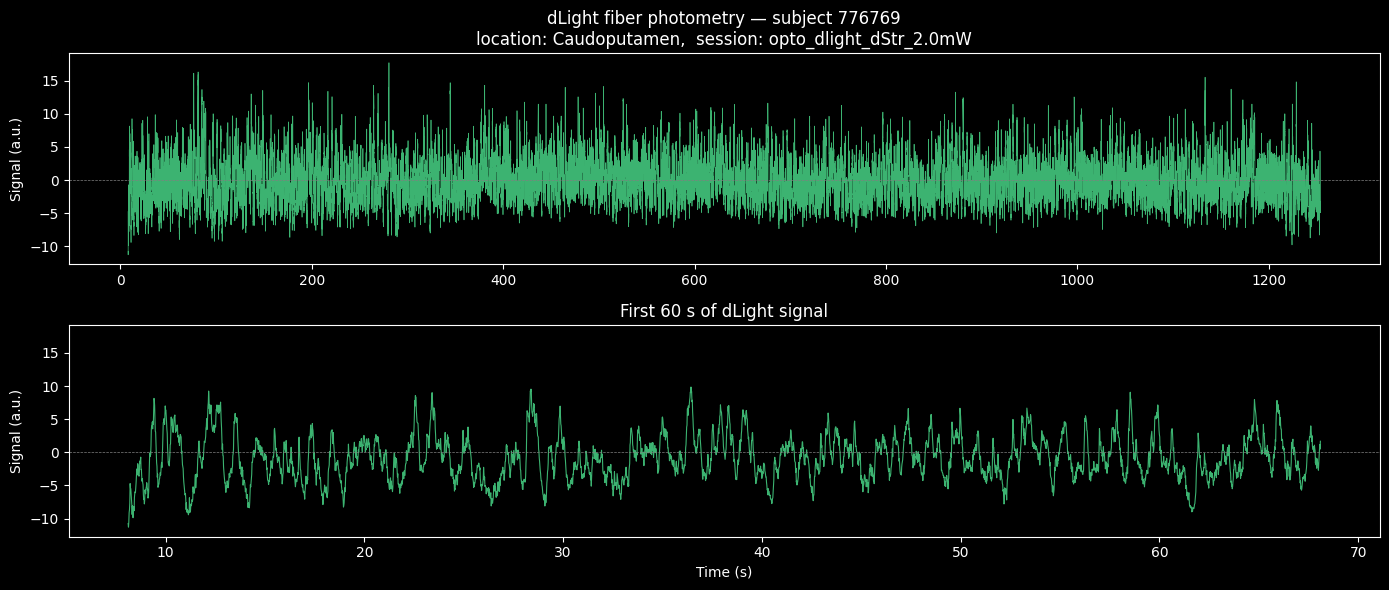

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharey=True)

# Full signal trace
axes[0].plot(timestamps, signal, linewidth=0.5, color="mediumseagreen")
axes[0].set_ylabel("Signal (a.u.)")
axes[0].set_title(
    f"dLight fiber photometry — subject {nwbfile.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile.session_id}"
)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Zoomed first 60 s window
t_end = min(timestamps[0] + 60, timestamps[-1])
mask = timestamps <= t_end
axes[1].plot(timestamps[mask], signal[mask], linewidth=0.8, color="mediumseagreen")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Signal (a.u.)")
axes[1].set_title(f"First 60 s of dLight signal")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

### Raw acquisition traces (470 nm signal + 405 nm isosbestic)

The raw fluorescence traces output directly by DoricStudio V5 are stored in `acquisition/`:

- **`FiberPhotometryResponseSeries`** — 470 nm excitation, dopamine-sensitive dLight1.3b fluorescence
- **`FiberPhotometryResponseSeriesIsosbestic`** — 405 nm isosbestic excitation, insensitive to dopamine; used as a motion artifact and photobleaching control

Both channels share the same timestamps and sampling rate (~60 Hz). The motion-corrected dF/F in
`processing/ophys/` is derived from these two channels (470 nm − 405 nm reference fit).

In [6]:
raw_sig = nwbfile.acquisition["FiberPhotometryResponseSeries"]
raw_ref = nwbfile.acquisition["FiberPhotometryResponseSeriesIsosbestic"]

sig_data = raw_sig.data[:]
ref_data = raw_ref.data[:]
raw_time = raw_sig.timestamps[:]

print(f"Signal (470 nm):    {sig_data.shape},  range [{sig_data.min():.1f}, {sig_data.max():.1f}] a.u.")
print(f"Reference (405 nm): {ref_data.shape},  range [{ref_data.min():.1f}, {ref_data.max():.1f}] a.u.")
print(f"Time range:         {raw_time[0]:.2f} – {raw_time[-1]:.2f} s")
print(f"Sampling rate:      ~{1 / np.median(np.diff(raw_time)):.1f} Hz")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Full session: both channels overlaid
axes[0].plot(raw_time, sig_data, linewidth=0.4, color="royalblue", label="470 nm signal")
axes[0].plot(raw_time, ref_data, linewidth=0.4, color="darkorange", alpha=0.85, label="405 nm isosbestic")
axes[0].set_ylabel("Fluorescence (a.u.)")
axes[0].set_title(
    f"Raw fiber photometry acquisition — subject {nwbfile.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile.session_id}"
)
axes[0].legend(fontsize=9)

# Zoomed first 60 s
t_end = min(raw_time[0] + 60, raw_time[-1])
mask = raw_time <= t_end
axes[1].plot(raw_time[mask], sig_data[mask], linewidth=0.8, color="royalblue", label="470 nm signal")
axes[1].plot(raw_time[mask], ref_data[mask], linewidth=0.8, color="darkorange", alpha=0.9, label="405 nm isosbestic")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Fluorescence (a.u.)")
axes[1].set_title("First 60 s — raw signal and isosbestic reference")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

KeyError: 'FiberPhotometryResponseSeries'

## 2. Optogenetic stimulation

The optogenetic TTL data is stored as an `OptogeneticSeries` in `stimulus/`. Values represent
laser power in **watts**: the session's intensity when the laser is on, 0 when off.

- **Target:** Bilateral SNc dopamine neurons (Anxa1-Flp mice expressing ChRmine)
- **Opsin:** ChRmine-oScarlet (AAV8-nEF-Coff/Fon-ChRmine-oScarlet, Addgene #137160)
- **Wavelength:** 640 nm (Cobalt solid-state laser)
- **Protocol:** 40 Hz laser, 1 s stimulation per nosepoke, 3 s inter-stimulation interval
- **Intensities tested:** 0.1, 0.2, 0.5, 1, 2 mW

**Note:** The first TTL burst corresponds to fiber photometry system activation and has been
excluded. All remaining bursts are nosepoke-triggered stimulation episodes.

In [7]:
ogen = nwbfile.stimulus["OptogeneticSeries"]
ogen_data = ogen.data[:]
ogen_rate = ogen.rate
ogen_start = ogen.starting_time
ogen_time = np.arange(len(ogen_data)) / ogen_rate + ogen_start

site = ogen.site
print(f"Site name:        {site.name}")
print(f"Location:         {site.location}")
print(f"Excitation λ:     {site.excitation_lambda} nm")
print(f"Site description: {site.description}")
print(f"\nSeries rate:      {ogen_rate:.2f} Hz")
print(f"Starting time:    {ogen_start:.3f} s")
print(f"Duration:         {len(ogen_data) / ogen_rate:.2f} s ({len(ogen_data)} samples)")
print(f"Intensity on:     {max(ogen_data) * 1000:.1f} mW  ({max(ogen_data):.4f} W)")

Site name:        OptogeneticStimulusSite
Location:         Substantia nigra, compact part
Excitation λ:     640.0 nm
Site description: Bilateral SNc optogenetic stimulation site. ChRmine (640 nm, 40 Hz, 2.0 mW). Anxa1-Flp mice expressing AAV8-nEF-Coff/Fon-ChRmine-oScarlet (Addgene #137160) bilaterally in SNc.

Series rate:      142.82 Hz
Starting time:    13.885 s
Duration:         353.49 s (50487 samples)
Intensity on:     2.0 mW  (0.0020 W)


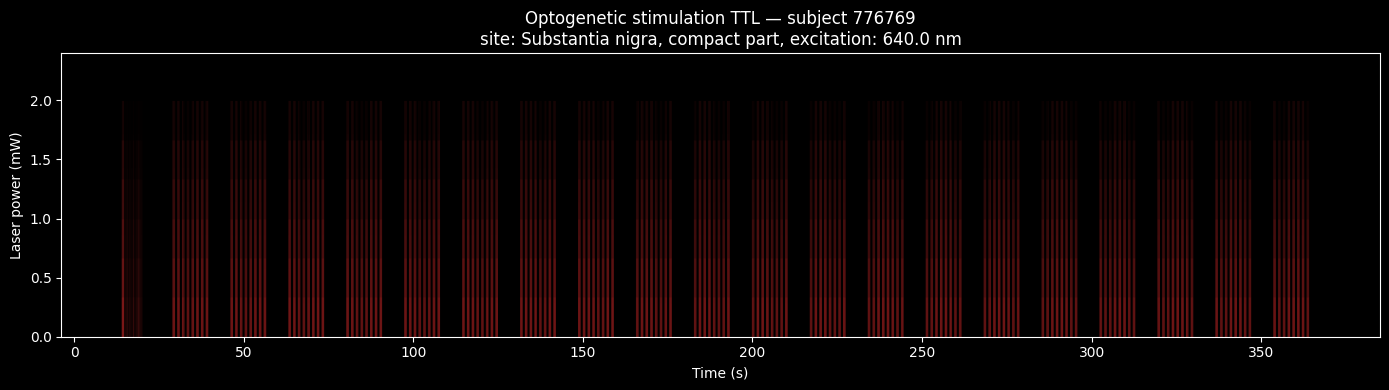

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(ogen_time, ogen_data * 1000, color="firebrick", alpha=0.8, linewidth=0)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Laser power (mW)")
ax.set_title(
    f"Optogenetic stimulation TTL — subject {nwbfile.subject.subject_id}\n"
    f"site: {site.location}, excitation: {site.excitation_lambda} nm"
)
ax.set_ylim(0, max(ogen_data) * 1000 * 1.2)

plt.tight_layout()
plt.show()

## 3. Stimulation episodes

Each nosepoke-triggered stimulation burst is stored as an interval in
`intervals/stimulation_episodes`. Each row records the onset and offset time of one 1-second
laser burst. The first TTL burst (fiber photometry activation) is excluded.

This `TimeIntervals` table allows easy peri-stimulus windowing of any other time series.

In [9]:
stim_episodes = nwbfile.intervals["stimulation_episodes"]
stim_df = stim_episodes.to_dataframe()

print(f"Total stimulation episodes: {len(stim_df)}")
print(f"\nFirst 5 episodes:")
print(stim_df.head())

durations = stim_df["stop_time"] - stim_df["start_time"]
isis = stim_df["start_time"].diff().dropna()

print(f"\nEpisode duration:     mean = {durations.mean():.3f} s,  std = {durations.std():.3f} s")
print(f"Inter-stim interval:  mean = {isis.mean():.3f} s,  std = {isis.std():.3f} s")

Total stimulation episodes: 163

First 5 episodes:
    start_time  stop_time
id                       
0    15.457088  21.502592
1    22.543936  27.507507
2    28.586061  34.067174
3    76.466662  77.444365
4    80.468954  81.445171

Episode duration:     mean = 1.060 s,  std = 0.612 s
Inter-stim interval:  mean = 7.588 s,  std = 9.570 s


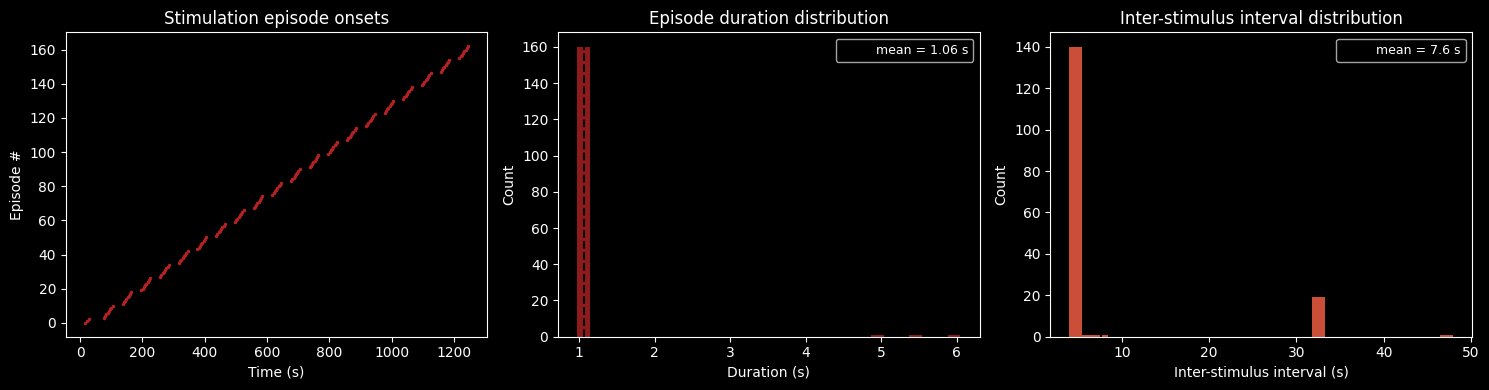

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(stim_df["start_time"], np.arange(len(stim_df)), ".", markersize=3, color="firebrick")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Episode #")
axes[0].set_title("Stimulation episode onsets")

axes[1].hist(durations, bins=30, color="firebrick", edgecolor="none", alpha=0.8)
axes[1].axvline(durations.mean(), color="black", linestyle="--", label=f"mean = {durations.mean():.2f} s")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Episode duration distribution")
axes[1].legend(fontsize=9)

axes[2].hist(isis, bins=30, color="tomato", edgecolor="none", alpha=0.8)
axes[2].axvline(isis.mean(), color="black", linestyle="--", label=f"mean = {isis.mean():.1f} s")
axes[2].set_xlabel("Inter-stimulus interval (s)")
axes[2].set_ylabel("Count")
axes[2].set_title("Inter-stimulus interval distribution")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Peri-stimulus dLight (triggered average)

Aligning the fiber photometry signal to stimulation onsets reveals the dopamine dynamics
triggered by nosepoke self-stimulation. Each trial is baseline-corrected to the mean of
the 2-second pre-stimulus window.

**Why only some trials are shown:** The protocol is 1 s laser ON + 3 s inter-stimulation
interval = 4 s between consecutive pokes within a self-stimulation bout. dLight1.3b
dopamine signals take 3–5 s to return to baseline after stimulation, so the pre-stimulus
window of any within-bout episode is contaminated by the tail of the previous response.
Only "bout-start" episodes are used here — those preceded by at least 5 s of rest
(gap from previous episode's stop time). This ensures a clean, uncontaminated baseline.

Bout-start trials: 21 / 163 total episodes


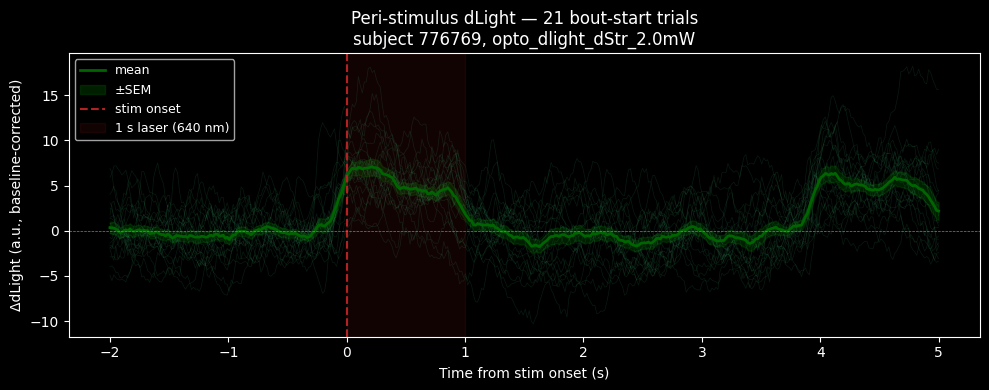

In [11]:
# Parameters
pre_s = 2.0   # seconds before stim onset
post_s = 5.0  # seconds after stim onset
min_gap_s = 5.0  # minimum gap from previous episode stop to current onset (bout-start filter)

fp_signal = nwbfile.processing["ophys"]["DfOverFFiberPhotometryResponseSeries"].data[:]
fp_time = nwbfile.processing["ophys"]["DfOverFFiberPhotometryResponseSeries"].timestamps[:]
stim_df = nwbfile.intervals["stimulation_episodes"].to_dataframe()
stim_onsets = stim_df["start_time"].values

dt = np.median(np.diff(fp_time))
fs = 1.0 / dt
n_pre = int(pre_s * fs)
n_post = int(post_s * fs)
n_samples = n_pre + n_post

trials = []
for i, onset in enumerate(stim_onsets):
    # Skip if pre-stim window starts before FP recording
    if onset - pre_s < fp_time[0]:
        continue
    # Keep only bout-start episodes: at least min_gap_s of rest since previous episode ended.
    # dLight1.3b takes 3-5 s to clear after stimulation; within-bout episodes (4 s ISI)
    # have contaminated pre-stim baselines.
    if i > 0 and (onset - stim_df["stop_time"].iloc[i - 1]) < min_gap_s:
        continue
    t_start = onset - pre_s
    t_end = onset + post_s
    mask = (fp_time >= t_start) & (fp_time < t_end)
    if mask.sum() >= n_samples * 0.9:
        t_grid = np.linspace(t_start, t_end, n_samples)
        snippet = np.interp(t_grid, fp_time[mask], fp_signal[mask])
        # Baseline-correct each trial to pre-stim mean
        snippet -= snippet[:n_pre].mean()
        trials.append(snippet)

t_axis = np.linspace(-pre_s, post_s, n_samples)
print(f"Bout-start trials: {len(trials)} / {len(stim_onsets)} total episodes")

if len(trials) > 0:
    trials_arr = np.array(trials)
    mean_trace = trials_arr.mean(axis=0)
    sem_trace = trials_arr.std(axis=0) / np.sqrt(len(trials))

    fig, ax = plt.subplots(figsize=(10, 4))
    for trial in trials_arr:
        ax.plot(t_axis, trial, color="mediumseagreen", alpha=0.15, linewidth=0.5)
    ax.plot(t_axis, mean_trace, color="darkgreen", linewidth=2, label="mean")
    ax.fill_between(t_axis, mean_trace - sem_trace, mean_trace + sem_trace,
                    color="darkgreen", alpha=0.3, label="±SEM")
    ax.axvline(0, color="firebrick", linestyle="--", linewidth=1.5, label="stim onset")
    ax.axvspan(0, 1, color="firebrick", alpha=0.1, label="1 s laser (640 nm)")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Time from stim onset (s)")
    ax.set_ylabel("ΔdLight (a.u., baseline-corrected)")
    ax.set_title(
        f"Peri-stimulus dLight — {len(trials)} bout-start trials\n"
        f"subject {nwbfile.subject.subject_id}, {nwbfile.session_id}"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(
        "No bout-start trials found — this is expected for the stub file.\n"
        "Load a full-session NWB file to see the peri-stimulus dLight response."
    )

## 5. Optogenetics metadata (ndx-optogenetics)

Rich device and virus metadata is stored via the
[ndx-optogenetics](https://github.com/catalystneuro/ndx-optogenetics) extension as
`OptogeneticExperimentMetadata` in `general/lab_meta_data/`. This includes:

- **ExcitationSourceModel** — Cobalt 640 nm solid-state laser model (manufacturer, source type,
  excitation mode, wavelength range)
- **ExcitationSource** — Laser instance linked to its model via `model=`; session-specific
  power in watts
- **OpticalFiberModel** — RWD R-FOC-BL200C-22NA model (200 µm, NA 0.22, ceramic ferrule)
- **OpticalFiber** — Bilateral SNc fibers linked to model; each with a `FiberInsertion`
  (AP −3.09, ML ±1.25, DV −3.9 mm from bregma at cortical surface)
- **Virus** — AAV8-nEF-Coff/Fon-ChRmine-oScarlet (Addgene #137160), 300 nL bilateral SNc
  injection (AP −3.09, ML ±1.25, DV −4.2 mm from bregma)
- **OptogeneticSitesTable** — One row per hemisphere linking effector, laser, and fiber

Stimulation target location uses the Allen Mouse Brain Atlas CCF name:
`Substantia nigra, compact part` (SNc).

In [12]:
opto_meta = nwbfile.lab_meta_data["optogenetic_experiment_metadata"]

print(f"Stimulation software:  {opto_meta.stimulation_software}")
print()

# Sites table summary (bilateral: left and right hemisphere)
sites_table = opto_meta.optogenetic_sites_table
n_rows = len(sites_table.to_dataframe())
print(f"Optogenetic sites table: {n_rows} rows (one per hemisphere)")
for i in range(n_rows):
    eff = sites_table["effector"][i]
    print(f"  row {i}: effector={eff.name}, label={eff.label}")
print()

# Excitation source (laser) — manufacturer/model info via model= linkage
laser = nwbfile.devices["laser"]
laser_model = laser.model
print(f"Excitation source:")
print(f"  name:         {laser.name}")
print(f"  manufacturer: {laser_model.manufacturer}")
print(f"  model name:   {laser_model.name}")
print(f"  power:        {laser.power_in_W * 1000:.1f} mW")
print()

# Optical fibers (bilateral) — manufacturer/model info via model= linkage
for side in ["left", "right"]:
    fiber = nwbfile.devices[f"optical_fiber_{side}"]
    fiber_model = fiber.model
    fi = fiber.fiber_insertion
    print(f"Optical fiber ({side}):")
    print(f"  manufacturer: {fiber_model.manufacturer}")
    print(f"  model:        {fiber_model.model_number}")
    print(f"  implant AP:   {fi.insertion_position_ap_in_mm} mm")
    print(f"  implant ML:   {fi.insertion_position_ml_in_mm} mm")
    print(f"  implant DV:   {fi.insertion_position_dv_in_mm} mm")
    print(f"  hemisphere:   {fi.hemisphere}")
    print()

Stimulation software:  Bonsai v2.6.3 (Lopes et al., 2015) + custom Arduino IDE script

Optogenetic sites table: 2 rows (one per hemisphere)
  row 0: effector=ChRmine_left, label=ChRmine
  row 1: effector=ChRmine_right, label=ChRmine

Excitation source:
  name:         laser
  manufacturer: Cobalt
  model name:   cobalt_640nm_laser_model
  power:        2.0 mW

Optical fiber (left):
  manufacturer: RWD
  model:        R-FOC-BL200C-22NA
  implant AP:   -3.09 mm
  implant ML:   -1.25 mm
  implant DV:   -3.9 mm
  hemisphere:   left

Optical fiber (right):
  manufacturer: RWD
  model:        R-FOC-BL200C-22NA
  implant AP:   -3.09 mm
  implant ML:   1.25 mm
  implant DV:   -3.9 mm
  hemisphere:   right



## 6. NWB file structure overview

Summary of all containers in this NWB file.

In [ ]:
print("=== Acquisition ===")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Processing ===")
for mod_name, mod in nwbfile.processing.items():
    print(f"  {mod_name}: {mod.description}")
    for name, obj in mod.data_interfaces.items():
        print(f"    {name}: {type(obj).__name__}")

print("\n=== Stimulus ===")
for name, obj in nwbfile.stimulus.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Intervals ===")
for name, obj in nwbfile.intervals.items():
    df = obj.to_dataframe()
    print(f"  {name}: {type(obj).__name__} ({len(df)} rows)")

print("\n=== Lab metadata ===")
for name, obj in nwbfile.lab_meta_data.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== OGen sites ===")
for name, obj in nwbfile.ogen_sites.items():
    print(f"  {name}: excitation_lambda={obj.excitation_lambda} nm, location={obj.location!r}")

print("\n=== Devices ===")
for name, obj in nwbfile.devices.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Device models (general/devices/models/) ===")
import h5py
with h5py.File(nwb_path, "r") as f:
    models_group = f.get("general/devices/models", {})
    for name in models_group:
        nt = models_group[name].attrs.get("neurodata_type", "?")
        print(f"  {name}: {nt}")

print("\n=== Subject ===")
s = nwbfile.subject
print(f"  subject_id: {s.subject_id}")
print(f"  species:    {s.species}")
print(f"  genotype:   {s.genotype}")
print(f"  strain:     {s.strain}")
print(f"  sex:        {s.sex}")

In [ ]:
io.close()